In [ ]:
from tensorboard.backend.event_processing import event_accumulator
import pandas as pd
from matplotlib import pyplot as plt

def print_tb(log_dir):
    ea = event_accumulator.EventAccumulator(log_dir)
    ea.Reload()
    scalar_tags = ea.Tags()['scalars']
    print(scalar_tags)

    if 'Car_3d/easy_R40' in scalar_tags:
        if 'Car_3d/easy_R40' in scalar_tags and 'Car_3d_relaxed/easy_R40' in scalar_tags:
            df_3d_reg = pd.DataFrame([(s.step, s.value) for s in ea.Scalars('Car_3d/easy_R40')], columns=['epoch', 'perf'])
            df_3d_rel = pd.DataFrame([(s.step, s.value) for s in ea.Scalars('Car_3d_relaxed/easy_R40')], columns=['epoch', 'perf'])
            df_bev_reg = pd.DataFrame([(s.step, s.value) for s in ea.Scalars('Car_bev/easy_R40')], columns=['epoch', 'perf'])
            df_bev_rel = pd.DataFrame([(s.step, s.value) for s in ea.Scalars('Car_bev_relaxed/easy_R40')], columns=['epoch', 'perf'])

            fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

            # --- Grafiek 1: Car 3D (Regular) [Links-boven] ---
            axs[0, 0].plot(df_3d_reg['epoch'], df_3d_reg['perf'], color='blue', linewidth=2)
            axs[0, 0].set_title('Car 3D (Regular)', fontweight='bold')
            axs[0, 0].set_ylabel('Performance')
            axs[0, 0].grid(True, linestyle='--', alpha=0.6)

            # --- Grafiek 2: Car 3D (Relaxed) [Rechts-boven] ---
            axs[0, 1].plot(df_3d_rel['epoch'], df_3d_rel['perf'], color='cyan', linewidth=2)
            axs[0, 1].set_title('Car 3D (Relaxed)', fontweight='bold')
            axs[0, 1].grid(True, linestyle='--', alpha=0.6)

            # --- Grafiek 3: Car BEV (Regular) [Links-onder] ---
            axs[1, 0].plot(df_bev_reg['epoch'], df_bev_reg['perf'], color='red', linewidth=2)
            axs[1, 0].set_title('Car BEV (Regular)', fontweight='bold')
            axs[1, 0].set_xlabel('Epoch')
            axs[1, 0].set_ylabel('Performance')
            axs[1, 0].grid(True, linestyle='--', alpha=0.6)

            # --- Grafiek 4: Car BEV (Relaxed) [Rechts-onder] ---
            axs[1, 1].plot(df_bev_rel['epoch'], df_bev_rel['perf'], color='orange', linewidth=2)
            axs[1, 1].set_title('Car BEV (Relaxed)', fontweight='bold')
            axs[1, 1].set_xlabel('Epoch')
            axs[1, 1].grid(True, linestyle='--', alpha=0.6)

            # 3. Voeg een overkoepelende titel toe en optimaliseer de tussenruimte
            plt.suptitle('Car Detection Performance Comparison (easy_R40)', fontsize=16, fontweight='bold', y=0.95)
            plt.tight_layout()

            # 4. Toon de grid
            plt.show()
            #print(pd.DataFrame(data, columns=['epoch', 'perf']))
        else:
            print("One of the required scalar tags is missing in the TensorBoard logs.")

    elif 'NDS' in scalar_tags:
        data = [(s.step, s.value) for s in ea.Scalars('NDS')]
        df = pd.DataFrame(data, columns=['Step', 'NDS'])
        df.plot(x='Step', y='NDS', kind='line', grid=True, title='NDS')
        plt.show()

    elif 'train/loss' in scalar_tags:
        data = [(s.step, s.value) for s in ea.Scalars('train/loss')]
        df = pd.DataFrame(data, columns=['Step', 'Loss'])
        df.plot(x='Step', y='Loss', kind='line', grid=True, title='Loss')
        plt.show()
    return 
    


In [3]:
log_test = {
    "P_D_def": {
        "K": "",
        "N": "",
        "E": "",
    },
    "P_T_def": {
        "K": "",
        "N": "",
        "E": "",
    },
    "S_D_def": {
        "K": "",
        "N": "",
        "E": "",
    },
    "S_F_def": {
        "K": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/F/S_F_K/default/eval/eval_all_default/default/tensorboard_val",
        "N": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/F/S_F_N/default/eval/eval_all_default/default/tensorboard_val",
        "E": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/F/S_F_E/default/eval/eval_all_default/default/tensorboard_val",
    },
    "S_T_def": {
        "K": "",
        "N": "",
        "E": "",
    },
    "P_D_ftd": {
        "K": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/D/S_D_K/default/eval/eval_all_default/default/tensorboard_val",
        "N": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/P/D/P_D_N/default/eval/eval_all_default/default/tensorboard_val",
        "E": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/P/D/P_D_E/default/eval/eval_all_default/default/tensorboard_val_all",
    },
    "P_T_ftd": {
        "K": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/P/T/P_T_K/default/eval/eval_all_default/default/tensorboard_val_all",
        "N": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/P/T/P_T_N/default/eval/eval_all_default/default/tensorboard_val_all",
        "E": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/P/T/P_T_E/default/eval/eval_all_default/default/tensorboard_val_all",
    },
    "S_D_ftd": {
        "K": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/D/S_D_K/default/eval/eval_all_default/default/tensorboard_val",
        "N": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/D/S_D_N/default/eval/eval_all_default/default/tensorboard_val",
        "E": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/D/S_D_E/default/eval/eval_all_default/default/tensorboard_val_all",
    },
    "S_F_ftd": {
        "K": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/F/S_F_K/default/eval/eval_all_default/default/tensorboard_val",
        "N": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/F/S_F_N/default/eval/eval_all_default/default/tensorboard_val_all",
        "E": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/F/S_F_E/default/eval/eval_all_default/default/tensorboard_val_all",
    },
    "S_T_ftd": {
        "K": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/T/S_T_K/default/eval/eval_all_default/default/tensorboard_val_all",
        "N": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/T/S_T_N/default/eval/eval_all_default/default/tensorboard_val_all",
        "E": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/T/S_T_E/default/eval/eval_all_default/default/tensorboard_val_all",
    }
}


In [4]:
log_train = {
    "P_ftd"       :"/OpenPCDet/output/OpenPCDet/tools/cfgs/models/P/D/P_D_N/unfrozen_backbone_1/tensorboard",
    "S_ftd"       :"",    
    "S_focals_def":"", 
    "S_focals_ftd":"",
    }



# TEST

## SECOND (DEFAULT)

2026-08-05 15:21:00.173884: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-05 15:21:00.896962: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


{'images': [], 'audio': [], 'histograms': [], 'scalars': ['recall/roi_0.3', 'recall/rcnn_0.3', 'recall/roi_0.5', 'recall/rcnn_0.5', 'recall/roi_0.7', 'recall/rcnn_0.7', 'Car_aos/easy_R40', 'Car_aos/moderate_R40', 'Car_aos/hard_R40', 'Car_3d/easy_R40', 'Car_3d/moderate_R40', 'Car_3d/hard_R40', 'Car_bev/easy_R40', 'Car_bev/moderate_R40', 'Car_bev/hard_R40', 'Car_image/easy_R40', 'Car_image/moderate_R40', 'Car_image/hard_R40', 'Car_3d_relaxed/easy_R40', 'Car_3d_relaxed/moderate_R40', 'Car_3d_relaxed/hard_R40', 'Car_bev_relaxed/easy_R40', 'Car_bev_relaxed/moderate_R40', 'Car_bev_relaxed/hard_R40', 'Car_image_relaxed/easy_R40', 'Car_image_relaxed/moderate_R40', 'Car_image_relaxed/hard_R40', 'Pedestrian_aos/easy_R40', 'Pedestrian_aos/moderate_R40', 'Pedestrian_aos/hard_R40', 'Pedestrian_3d/easy_R40', 'Pedestrian_3d/moderate_R40', 'Pedestrian_3d/hard_R40', 'Pedestrian_bev/easy_R40', 'Pedestrian_bev/moderate_R40', 'Pedestrian_bev/hard_R40', 'Pedestrian_image/easy_R40', 'Pedestrian_image/modera

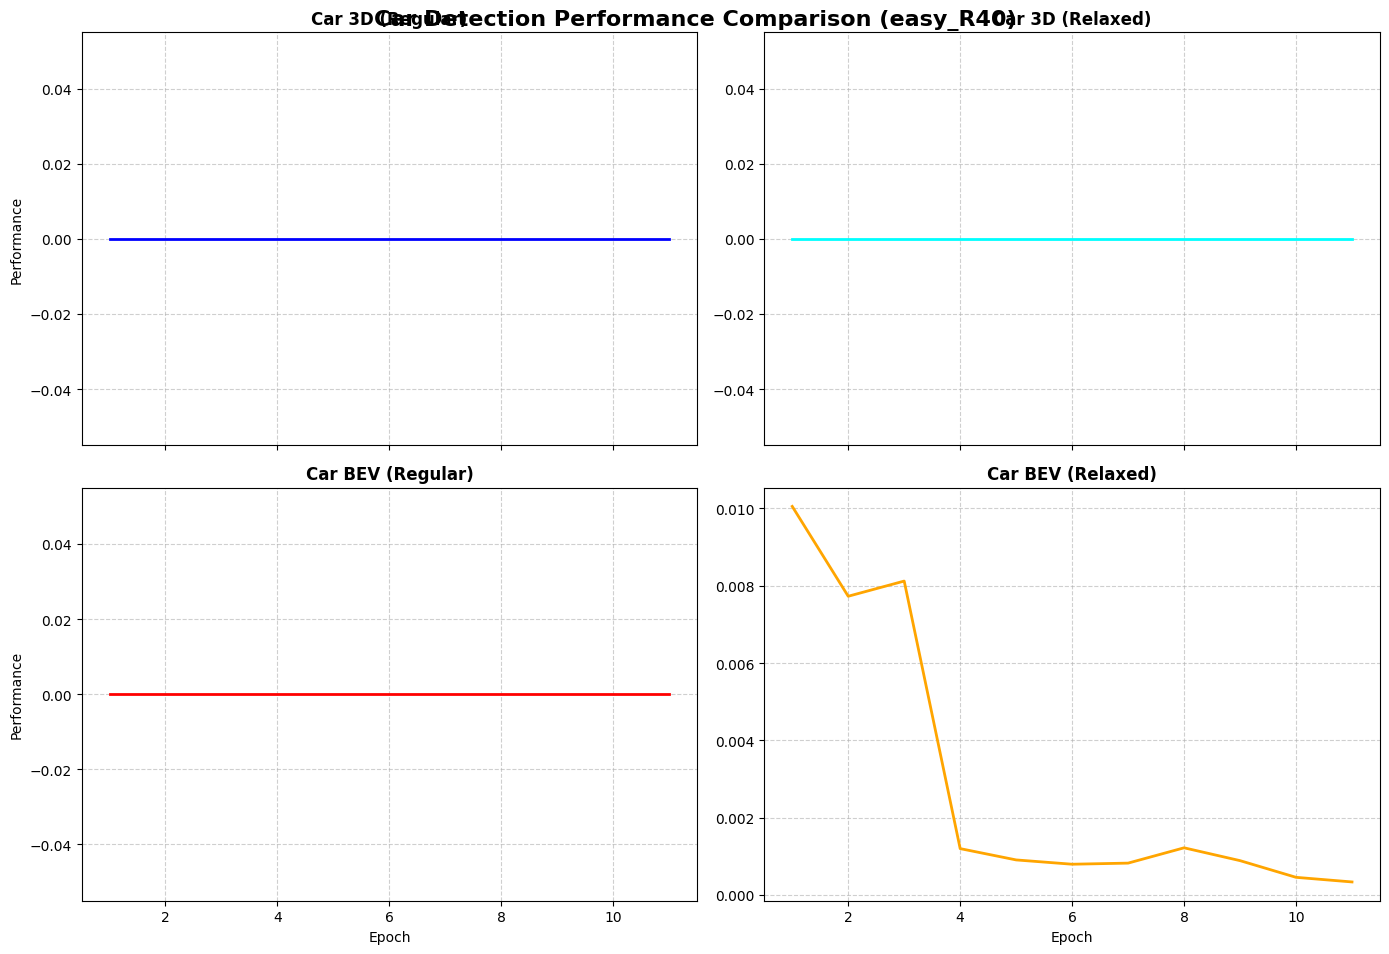

In [4]:
print_tb(log_test["S_D_ftd"]["K"])

In [5]:
#print_tb(log_test["S_D_ftd"]["N"])

In [6]:
print_tb(log_test["S_D_ftd"]["E"])

{'images': [], 'audio': [], 'histograms': [], 'scalars': ['recall/roi_0.3', 'recall/rcnn_0.3', 'recall/roi_0.5', 'recall/rcnn_0.5', 'recall/roi_0.7', 'recall/rcnn_0.7', 'Car_aos/easy_R40', 'Car_aos/moderate_R40', 'Car_aos/hard_R40', 'Car_3d/easy_R40', 'Car_3d/moderate_R40', 'Car_3d/hard_R40', 'Car_bev/easy_R40', 'Car_bev/moderate_R40', 'Car_bev/hard_R40', 'Car_image/easy_R40', 'Car_image/moderate_R40', 'Car_image/hard_R40', 'Pedestrian_aos/easy_R40', 'Pedestrian_aos/moderate_R40', 'Pedestrian_aos/hard_R40', 'Pedestrian_3d/easy_R40', 'Pedestrian_3d/moderate_R40', 'Pedestrian_3d/hard_R40', 'Pedestrian_bev/easy_R40', 'Pedestrian_bev/moderate_R40', 'Pedestrian_bev/hard_R40', 'Pedestrian_image/easy_R40', 'Pedestrian_image/moderate_R40', 'Pedestrian_image/hard_R40', 'Cyclist_aos/easy_R40', 'Cyclist_aos/moderate_R40', 'Cyclist_aos/hard_R40', 'Cyclist_3d/easy_R40', 'Cyclist_3d/moderate_R40', 'Cyclist_3d/hard_R40', 'Cyclist_bev/easy_R40', 'Cyclist_bev/moderate_R40', 'Cyclist_bev/hard_R40', 'Cyc

KeyError: 'Key Car_3d_relaxed/easy_R40 was not found in Reservoir'

## SECOND (FOCALS)

{'images': [], 'audio': [], 'histograms': [], 'scalars': ['recall/roi_0.3', 'recall/rcnn_0.3', 'recall/roi_0.5', 'recall/rcnn_0.5', 'recall/roi_0.7', 'recall/rcnn_0.7', 'Car_aos/easy_R40', 'Car_aos/moderate_R40', 'Car_aos/hard_R40', 'Car_3d/easy_R40', 'Car_3d/moderate_R40', 'Car_3d/hard_R40', 'Car_bev/easy_R40', 'Car_bev/moderate_R40', 'Car_bev/hard_R40', 'Car_image/easy_R40', 'Car_image/moderate_R40', 'Car_image/hard_R40', 'Car_3d_relaxed/easy_R40', 'Car_3d_relaxed/moderate_R40', 'Car_3d_relaxed/hard_R40', 'Car_bev_relaxed/easy_R40', 'Car_bev_relaxed/moderate_R40', 'Car_bev_relaxed/hard_R40', 'Car_image_relaxed/easy_R40', 'Car_image_relaxed/moderate_R40', 'Car_image_relaxed/hard_R40', 'Pedestrian_aos/easy_R40', 'Pedestrian_aos/moderate_R40', 'Pedestrian_aos/hard_R40', 'Pedestrian_3d/easy_R40', 'Pedestrian_3d/moderate_R40', 'Pedestrian_3d/hard_R40', 'Pedestrian_bev/easy_R40', 'Pedestrian_bev/moderate_R40', 'Pedestrian_bev/hard_R40', 'Pedestrian_image/easy_R40', 'Pedestrian_image/modera

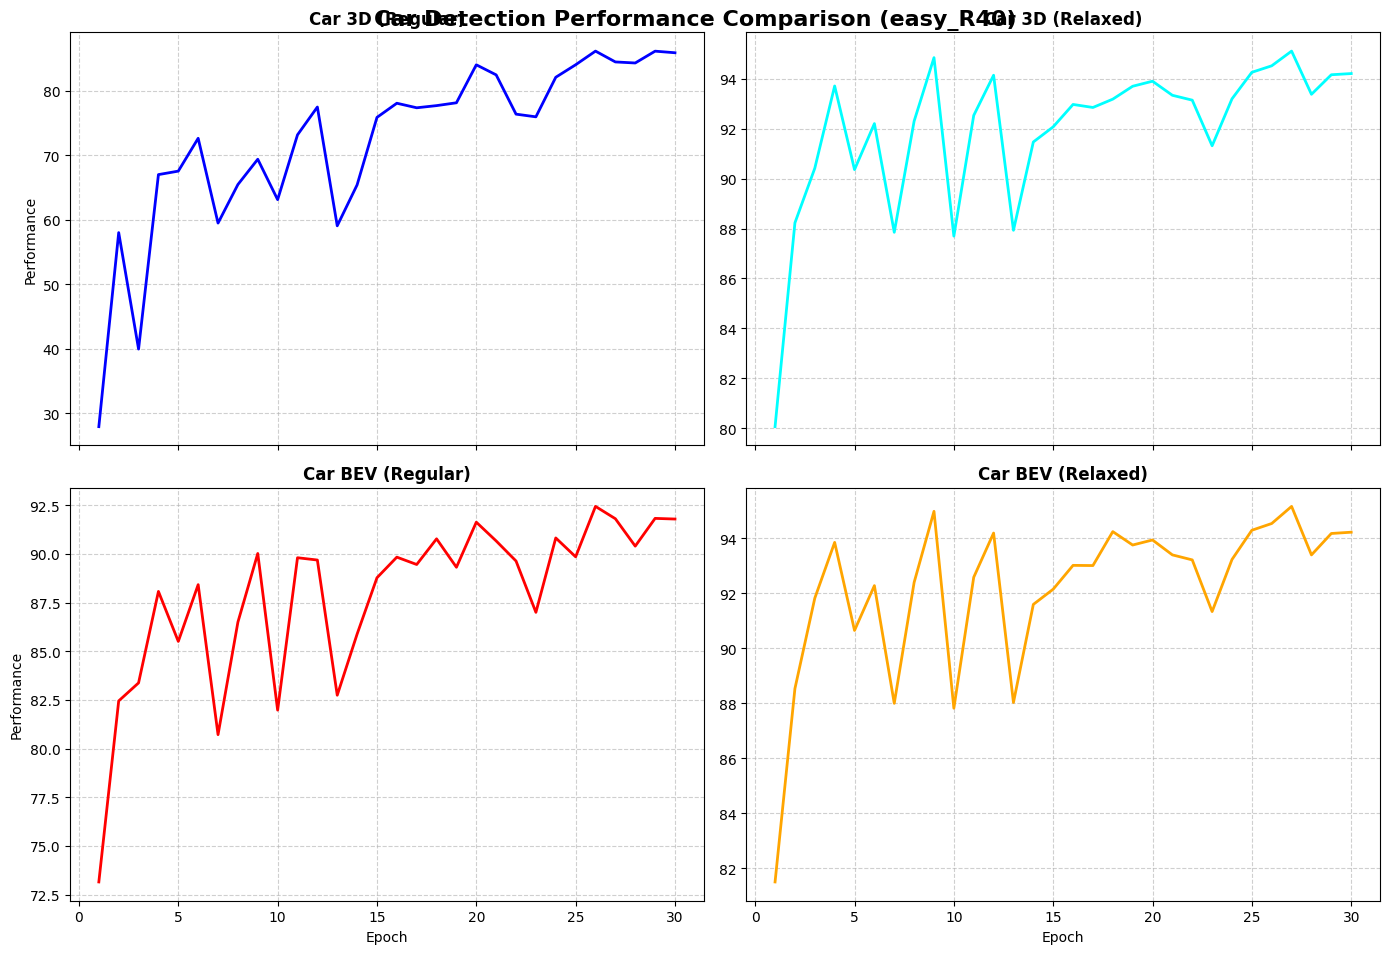

In [6]:
print_tb(log_test["S_F_def"]["K"])

In [11]:
print_tb(log_test["S_F_def"]["N"])

{'images': [], 'audio': [], 'histograms': [], 'scalars': ['recall/roi_0.3', 'recall/rcnn_0.3', 'recall/roi_0.5', 'recall/rcnn_0.5', 'recall/roi_0.7', 'recall/rcnn_0.7', 'trans_err', 'scale_err', 'orient_err', 'vel_err', 'attr_err', 'mAP', 'NDS'], 'distributions': [], 'tensors': [], 'graph': False, 'meta_graph': False, 'run_metadata': []}


KeyError: 'Key Car_3d/easy_R40 was not found in Reservoir'

In [ ]:
print_tb(log_test["S_F_def"]["E"])

In [ ]:
print_tb(log_test["S_F_ftd"]["K"])

In [ ]:
print_tb(log_test["S_F_ftd"]["N"])

In [ ]:
print_tb(log_test["S_F_ftd"]["E"])

## SECOND (TENT)

In [ ]:
print_tb(log_test["S_T_ftd"]["K"])

In [ ]:
print_tb(log_test["S_T_ftd"]["N"])

In [ ]:
print_tb(log_test["S_T_ftd"]["E"])

## POINTPILLARS (DEFAULT)

In [ ]:
print_tb(log_test["P_D_ftd"]["K"])

In [ ]:
print_tb(log_test["P_D_ftd"]["N"])

In [ ]:
print_tb(log_test["P_D_ftd"]["E"])

## POINTPILLARS (TENT)

In [ ]:
print_tb(log_test["P_T_ftd"]["K"])

In [ ]:
print_tb(log_test["P_T_ftd"]["N"])

In [ ]:
print_tb(log_test["P_T_ftd"]["E"])